In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

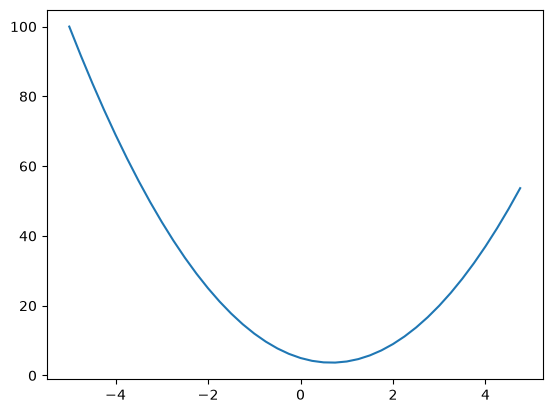

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x))/h

0.0

In [7]:
class Value:
    def __init__(self, data, _children=(), _op="", label=''):
        self.data = data # the data
        self.grad = 0.0 # default assumption for each data
        self._backward = lambda: None # does not do anything by default, say leaf nodes
        self._prev = set(_children) # to construct graph by recording prev values
        self._op = _op # recording operation
        self.label= label # label for graphviz only...?

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward(): # already accounts for accumulation, no need to check again
          self.grad += 1.0 * out.grad # for addition, it just propagates
          other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other): # add fix, even more useful during subtraction
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
          self.grad += other.data * out.grad # for mul, its alternate value x value of prev upper layer
          other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # multiplier fix
        return self * other

    def __truediv__(self, other): # easy to use **-1
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), '# what other data types do I need to include'
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def exp(self): # for exponential in tanh, but idk, might be useful somewhere else
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
          self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
          self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    # now, implementing topo-sort in actual backprop logic
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
          node._backward()
                 
# fwd pass (simple)
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data=-8.0)

In [8]:
L._prev

{Value(data=-2.0), Value(data=4.0)}

In [9]:
L._op

'*'

In [10]:
from graphviz import Digraph

def trace(root):
  #  this builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR -> left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # creeate record node, rectangular in shape, for any value in the graph
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if value = result of operation; create op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect node1 to the op node of node2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

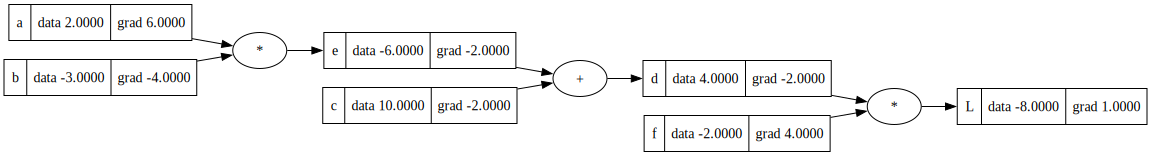

In [11]:
a.grad = 6.0
b.grad = -4.0
c.grad = -2.0
e.grad = -2.0
f.grad = 4.0
d.grad = -2.0
L.grad = 1.0
draw_dot(L)

In [12]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [13]:
def trial_grad():
    # to validate my weak calculus; update: not thaaat weak I guess 
    # h
    h = 0.001
    
    # f(x)
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data

    # f(x+h)
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'   
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data

    # (f(x+h) - f(x))/h; depends on value touched with h, here dL/d_
    print ((L2 - L1)/h)

trial_grad()

0.0


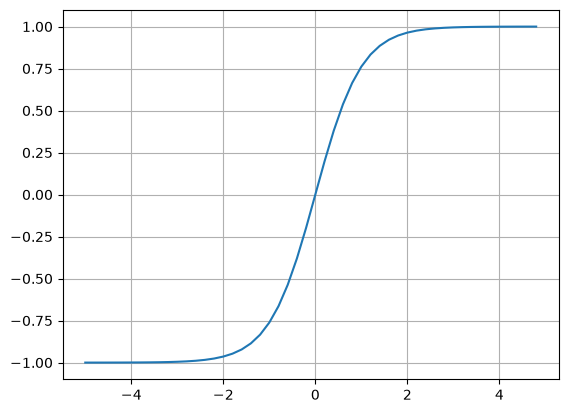

In [14]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

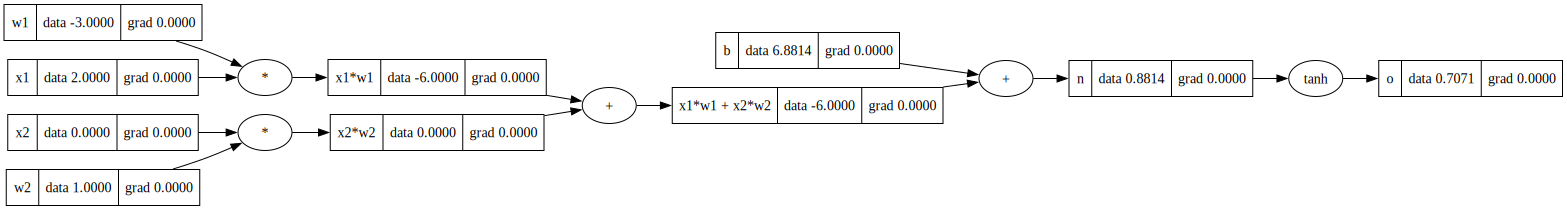

In [25]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh() ; o.label = 'o'

draw_dot(o)

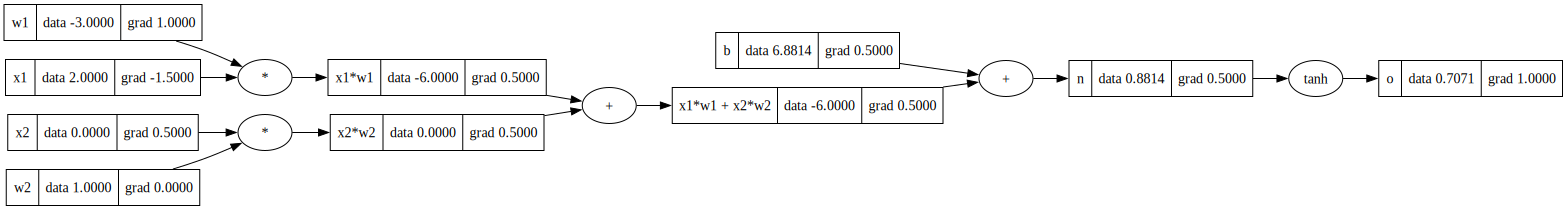

In [27]:
draw_dot(o)

In [26]:
o.backward()

In [18]:
# now to fix and actually do backprop properly, using topo-sort
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [19]:
o.grad = 1.0 # initialize, and its actually 1
o._backward() # testing backprop onebyone

In [20]:
n._backward()

In [21]:
b._backward() # nothing should happen

In [22]:
x1w1x2w2._backward()

In [23]:
x1w1._backward()
x2w2._backward()

In [153]:
'''o.grad = 1.0

# filling in therefore
n.grad = 0.5

# therefore, by virtue:
x1w1x2w2.grad = 0.5
b.grad = 0.5

# therefore, again by virtue:
x1w1.grad = 0.5
x2w2.grad = 0.5

# finally:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

# beware this is only 1 pass, millions of passes are actually required'''

In [28]:
o.data

0.7071067811865476

In [29]:
1-o.data**2

0.4999999999999999

In [136]:
# o = tanh(n)
# therefore, do/dn = 1 - tanh(n)**2; more cleanly, do/dn = 1 - o**2
# no point using sech(n)**2

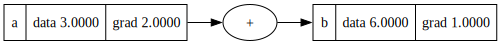

In [30]:
#andrej's one of the checks for badness, picked from micrograd:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

In [ ]:
#I passed!

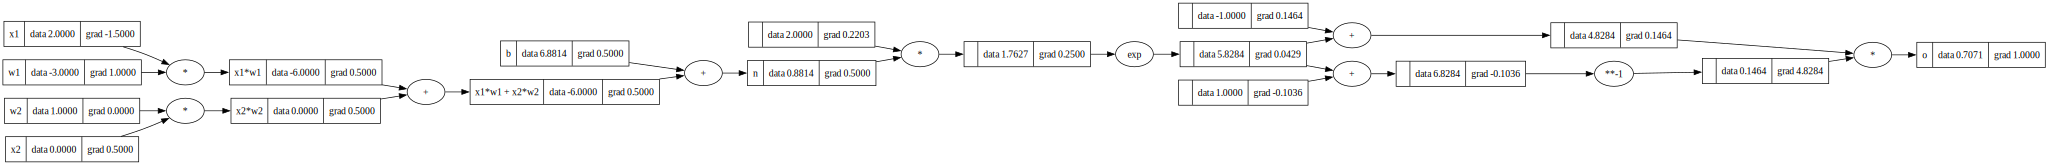

In [31]:
# now drawing tanh ffrom scratch:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [32]:
class Neuron: #NOT TESTED YET
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [37]:
x = [1.0, 2.0, 3.0]
n = MLP(7, [5, 3, 1])
n(x)

Value(data=0.434754976397036)

In [38]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [39]:
for k in range(200):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.01 * p.grad
  
  print(k, loss.data)
  

0 3.0963220254933126
1 2.8035075721822
2 2.52348414479482
3 2.2528371878732725
4 1.9983362635813626
5 1.7692326463311563
6 1.5707600542920657
7 1.4020957059339778
8 1.2586427307275656
9 1.1352011735629328
10 1.02763461375896
11 0.9330701574901681
12 0.8495251953890027
13 0.7755298189423456
14 0.7098962929197686
15 0.6516075363437781
16 0.5997696922363073
17 0.5535921224884688
18 0.5123769251716311
19 0.475510874138323
20 0.4424575840509317
21 0.41274956340912117
22 0.38598036715016126
23 0.361797124765341
24 0.33989364216736034
25 0.3200041808745217
26 0.30189794360079036
27 0.2853742462181539
28 0.2702583277414351
29 0.25639773633140917
30 0.24365922510401028
31 0.2319260929659257
32 0.22109591020286587
33 0.21107857448563627
34 0.2017946493315967
35 0.1931739432898903
36 0.18515429390277663
37 0.17768052569416104
38 0.17070355601074416
39 0.16417962650786921
40 0.1580696414770366
41 0.15233859711389128
42 0.1469550882862487
43 0.14189088144130163
44 0.13712054404461585
45 0.132621122

In [40]:
ypred

[Value(data=0.9370345615261814),
 Value(data=-0.9761287782910815),
 Value(data=-0.9131969298203144),
 Value(data=0.9247422065592772)]